# BondFlow Benchmark Visualization Analysis

This notebook loads the 4 `benchmark_level_summary.csv` files you provided and generates 4 plots with consistent model colors and legends.

Required data fields include:
- Binding affinity: `Binding_Energy_Mean` vs reference: `Benchmark_Binding_Energy_dG`
- Cyclization success rate: `Cyclization_Success_Rate` and cyclization type proportions (derived from `Cyclization_Type_Count_*`)
- Structural diversity: `Ligand_Diversity_MeanPairTM_minus1`
- Secondary-structure proportions: `Design_SS_Freq_{H,E,C}` vs reference: `Ref_SS_Freq_{H,E,C}`


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

base_dir = "/home/xjt/BondFlow"
csv_paths = {
    "RFpeptide+MPNN": os.path.join(base_dir, "mydata/rfdiffusion_mpnn_outputs_64_eval/benchmark_level_summary.csv"),
    "DiffPepBuilder": os.path.join(base_dir, "mydata/diffpepbuilder_allpdb_8gpu_64design2_eval_full/benchmark_level_summary.csv"),
    "ColabDesign": os.path.join(base_dir, "mydata/colabdesign_full_eval_all/benchmark_level_summary.csv"),
    "BondFlow": os.path.join(base_dir, "mydata/bondflow_eval_results/benchmark_level_summary.csv"),
}

model_order = ["BondFlow", "RFpeptide+MPNN", "DiffPepBuilder", "ColabDesign"]
model_colors = {
    "BondFlow": "#1f77b4",
    "RFpeptide+MPNN": "#ff7f0e",
    "DiffPepBuilder": "#2ca02c",
    "ColabDesign": "#d62728",
    "Reference": "#7f7f7f",
}

# Cyclization types (used for stacked-bar segment colors)
merged_head_tail_col = "Cyclization_Type_Count_head_tail_plus_other"

cyclization_type_order = [
    "disulfide",
    "isopeptide",
    "lactone",
    "head_tail",
]
cyclization_type_label = {
    "disulfide": "Disulfide",
    "isopeptide": "Amide bond (isopeptide)",
    "lactone": "Lactone",
    "head_tail": "Head-to-tail cyclization",
}
cyclization_type_colors = {
    "disulfide": "#9467bd",
    "isopeptide": "#8c564b",
    "lactone": "#e377c2",
    "head_tail": "#17becf",
}

design_ss_cols = {"H": "Design_SS_Freq_H", "E": "Design_SS_Freq_E", "C": "Design_SS_Freq_C"}
ref_ss_cols = {"H": "Ref_SS_Freq_H", "E": "Ref_SS_Freq_E", "C": "Ref_SS_Freq_C"}

cyclization_count_cols = {
    "disulfide": "Cyclization_Type_Count_disulfide",
    "isopeptide": "Cyclization_Type_Count_isopeptide",
    "lactone": "Cyclization_Type_Count_lactone",
    "head_tail": merged_head_tail_col,
}


In [ ]:
# Read and align benchmarks (keep only those present in all models)

dfs = {}
benchmark_sets = []
for model, path in csv_paths.items():
    df = pd.read_csv(path)
    dfs[model] = df
    benchmark_sets.append(set(df["Benchmark"].astype(str).tolist()))

common_benchmarks = sorted(set.intersection(*benchmark_sets))
print("Number of common benchmarks across all models: ", len(common_benchmarks))

for model in dfs:
    dfs[model] = dfs[model][dfs[model]["Benchmark"].astype(str).isin(common_benchmarks)].copy()

# Merge head-to-tail cyclization with the 'other' category (other is treated as head-to-tail)
for model in dfs:
    dfs[model][merged_head_tail_col] = (
        pd.to_numeric(dfs[model]["Cyclization_Type_Count_head_tail"], errors="coerce").fillna(0.0)
        + pd.to_numeric(dfs[model]["Cyclization_Type_Count_other"], errors="coerce").fillna(0.0)
    )

# Reference binding affinity and secondary-structure proportions come from any one CSV
ref_source_df = next(iter(dfs.values()))

df_reference = ref_source_df[[
    "Benchmark",
    "Benchmark_Binding_Energy_dG",
    ref_ss_cols["H"],
    ref_ss_cols["E"],
    ref_ss_cols["C"],
]].copy()

df_reference["Benchmark"] = df_reference["Benchmark"].astype(str)
# Ensure consistent ordering

df_reference = df_reference.set_index("Benchmark").loc[common_benchmarks].reset_index()
df_reference = df_reference.rename(columns={"Benchmark_Binding_Energy_dG": "Reference_Binding_Energy_dG"})

df_reference.head()


Number of common benchmarks across all models:  16


,Benchmark,Reference_Binding_Energy_dG,Ref_SS_Freq_H,Ref_SS_Freq_E,Ref_SS_Freq_C
0,1sfi,-41.938459,0.0,0.285714,0.714286
1,3av9,-41.598416,0.0,0.250000,0.750000
2,3avg,-38.857415,0.0,0.250000,0.750000
3,3wne,-27.769919,0.0,0.000000,1.000000
4,3wng,-34.586475,0.0,0.000000,1.000000


In [ ]:
def compute_affinity_long(dfs_dict):
    rows = []
    for model in model_order:
        dfm = dfs_dict[model].set_index("Benchmark").loc[common_benchmarks].reset_index()
        rows.append(pd.DataFrame({
            "Model": model,
            "Benchmark": dfm["Benchmark"].astype(str),
            "Affinity": pd.to_numeric(dfm["Binding_Energy_Mean"], errors="coerce"),
        }))

    df_long = pd.concat(rows, ignore_index=True)

    # reference
    df_ref = pd.DataFrame({
        "Model": "Reference",
        "Benchmark": df_reference["Benchmark"].astype(str),
        "Affinity": pd.to_numeric(df_reference["Reference_Binding_Energy_dG"], errors="coerce"),
    })

    return pd.concat([df_long, df_ref], ignore_index=True)


def compute_cyclization_type_segments_for_model(df_model):
    # segment height = mean(success_benchmark * type_proportion_benchmark)
    success = pd.to_numeric(df_model["Cyclization_Success_Rate"], errors="coerce").fillna(0.0).to_numpy()

    # (N, num_types)
    counts = []
    for t in cyclization_type_order:
        col = cyclization_count_cols[t]
        counts.append(pd.to_numeric(df_model[col], errors="coerce").fillna(0.0).to_numpy())
    counts = np.stack(counts, axis=1)

    total = counts.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        props = np.where(total > 0, counts / total, 0.0)

    seg_heights = (success[:, None] * props).mean(axis=0)

    return {t: float(h) for t, h in zip(cyclization_type_order, seg_heights)}


def infer_reference_cyclization_type_by_majority(dfs_dict):
    """
    The provided CSVs do not include an explicit reference cyclization type field, so this notebook infers it via a weighted vote of each model's dominant cyclization type.

    - For each benchmark:
      - Infer the dominant cyclization type from each model using `Cyclization_Type_Count_*`
      - Use that model's `Cyclization_Success_Rate` for weighted voting
    - Select the top-voted type as the reference cyclization type.
    """
    ref_type_by_bench = {}
    for b in common_benchmarks:
        vote = {t: 0.0 for t in cyclization_type_order}
        for model in model_order:
            dfm = dfs_dict[model]
            row = dfm[dfm["Benchmark"].astype(str) == str(b)].iloc[0]

            success = pd.to_numeric(row["Cyclization_Success_Rate"], errors="coerce")
            success = float(success) if pd.notna(success) else 0.0

            counts = []
            for t in cyclization_type_order:
                col = cyclization_count_cols[t]
                val = pd.to_numeric(row[col], errors="coerce")
                counts.append(float(val) if pd.notna(val) else 0.0)
            counts = np.array(counts, dtype=float)
            total = float(counts.sum())
            if total <= 0:
                continue

            props = counts / total
            dom_idx = int(np.argmax(props))
            dom_type = cyclization_type_order[dom_idx]
            vote[dom_type] += success

        best_type, best_score = max(vote.items(), key=lambda kv: kv[1])
        if best_score <= 0:
            best_type = "head_tail"

        ref_type_by_bench[b] = best_type

    return ref_type_by_bench


ref_type_by_bench = infer_reference_cyclization_type_by_majority(dfs)


def plot_affinity_box(ax, df_affinity, order):
    data = []
    labels = []
    colors = []
    for m in order:
        vals = pd.to_numeric(df_affinity[df_affinity["Model"] == m]["Affinity"], errors="coerce").dropna().to_numpy()
        data.append(vals)
        labels.append(m)
        colors.append(model_colors[m])

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.85)

    ax.set_ylabel("Binding affinity dG (Binding Energy)")
    ax.set_title("Binding affinity comparison across models (including Reference)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)


def plot_diversity_box(ax, dfs_dict):
    data = []
    labels = []
    colors = []
    for m in model_order:
        dfm = dfs_dict[m].set_index("Benchmark").loc[common_benchmarks].reset_index()
        vals = -pd.to_numeric(dfm["Ligand_Diversity_MeanPairTM_minus1"], errors="coerce").dropna().to_numpy()
        data.append(vals)
        labels.append(m)
        colors.append(model_colors[m])

    bp = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.85)

    ax.set_ylabel("Structural diversity: -(MeanPairTM - 1)")
    ax.set_title("Structural diversity comparison across models (boxplot)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)


def plot_cyclization_stacked_success(ax, dfs_dict, ref_type_map):
    # Compute stacked segments for each model (segment heights sum to that model's mean success)
    models_with_ref = model_order + ["Reference"]
    seg_by_model = {m: {} for m in models_with_ref}

    for m in model_order:
        dfm = dfs_dict[m].set_index("Benchmark").loc[common_benchmarks].reset_index()
        seg_by_model[m] = compute_cyclization_type_segments_for_model(dfm)

    # Reference cyclization type is inferred per benchmark; success is always 1
    # Segment height = number of benchmarks of that type / N
    n = len(common_benchmarks)
    for t in cyclization_type_order:
        k = sum(1 for b in common_benchmarks if ref_type_map.get(b) == t)
        seg_by_model["Reference"][t] = k / n

    x = np.arange(len(models_with_ref))
    width = 0.65

    for i, m in enumerate(models_with_ref):
        bottom = 0.0
        for t in cyclization_type_order:
            h = float(seg_by_model[m].get(t, 0.0))
            ax.bar(
                i,
                h,
                width=width,
                bottom=bottom,
                color=cyclization_type_colors[t],
                edgecolor=model_colors[m],
                linewidth=1.0,
            )
            bottom += h

    ax.set_xticks(x)
    ax.set_xticklabels(models_with_ref, rotation=15, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("Cyclization success rate (mean)")
    ax.set_title("Cyclization success rate comparison across models (stacked by cyclization type)")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    legend_handles = [Patch(color=cyclization_type_colors[t], label=cyclization_type_label[t]) for t in cyclization_type_order]
    ax.legend(handles=legend_handles, title="Cyclization type", loc="upper right", frameon=True)


def plot_secondary_structure_stacked(ax, dfs_dict):
    # Stacked bar showing mean proportion of H/E/C
    models_with_ref = model_order + ["Reference"]
    ss_types = ["H", "E", "C"]
    ss_colors = {"H": "#1f77b4", "E": "#ff7f0e", "C": "#2ca02c"}
    ss_labels = {"H": "Alpha helix (H)", "E": "Beta sheet (E)", "C": "Random coil (C)"}

    means = {m: {} for m in models_with_ref}

    for m in model_order:
        dfm = dfs_dict[m].set_index("Benchmark").loc[common_benchmarks].reset_index()
        for st in ss_types:
            means[m][st] = float(pd.to_numeric(dfm[design_ss_cols[st]], errors="coerce").fillna(0.0).mean())

    for st in ss_types:
        means["Reference"][st] = float(pd.to_numeric(df_reference[ref_ss_cols[st]], errors="coerce").fillna(0.0).mean())

    x = np.arange(len(models_with_ref))
    width = 0.65
    bottom = np.zeros(len(models_with_ref))

    for st in ss_types:
        heights = [means[m][st] for m in models_with_ref]
        ax.bar(
            x,
            heights,
            width=width,
            bottom=bottom,
            color=ss_colors[st],
            edgecolor="black",
            linewidth=0.6,
            label=ss_labels[st],
        )
        bottom += np.array(heights)

    ax.set_xticks(x)
    ax.set_xticklabels(models_with_ref, rotation=15, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel("Secondary structure proportion (mean)")
    ax.set_title("Secondary structure proportion comparison across models (including Reference)")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(loc="upper right", frameon=True)


/tmp/ipykernel_1640547/1787125736.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


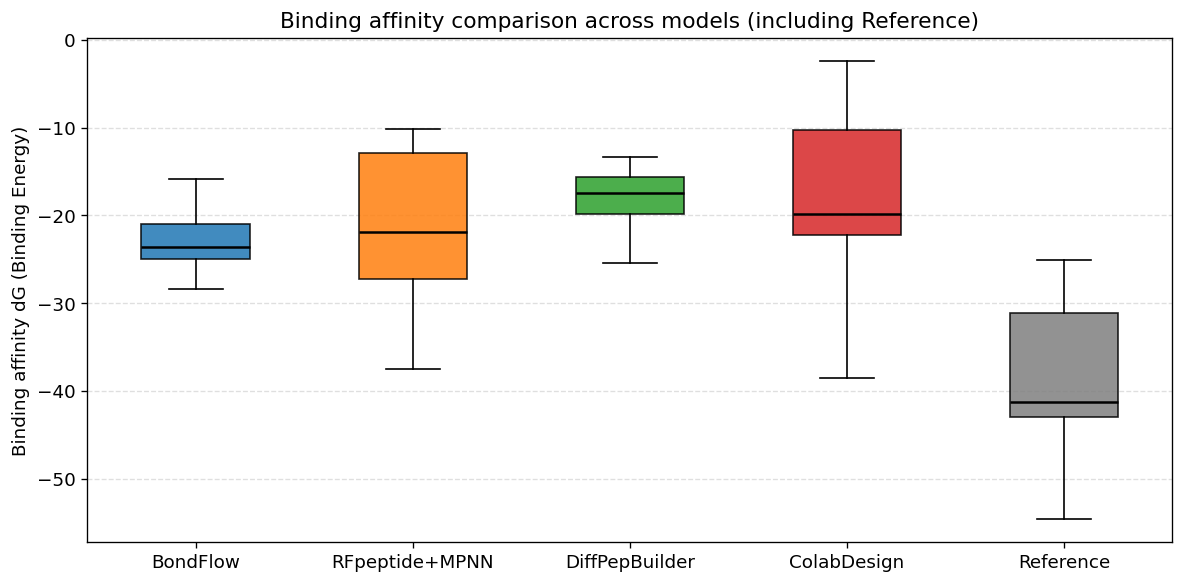

In [ ]:
# 1. Binding affinity comparison (including reference)
df_affinity = compute_affinity_long(dfs)

affinity_order = model_order + ["Reference"]

fig, ax = plt.subplots(figsize=(10, 5))
plot_affinity_box(ax, df_affinity, affinity_order)
plt.tight_layout()
plt.show()


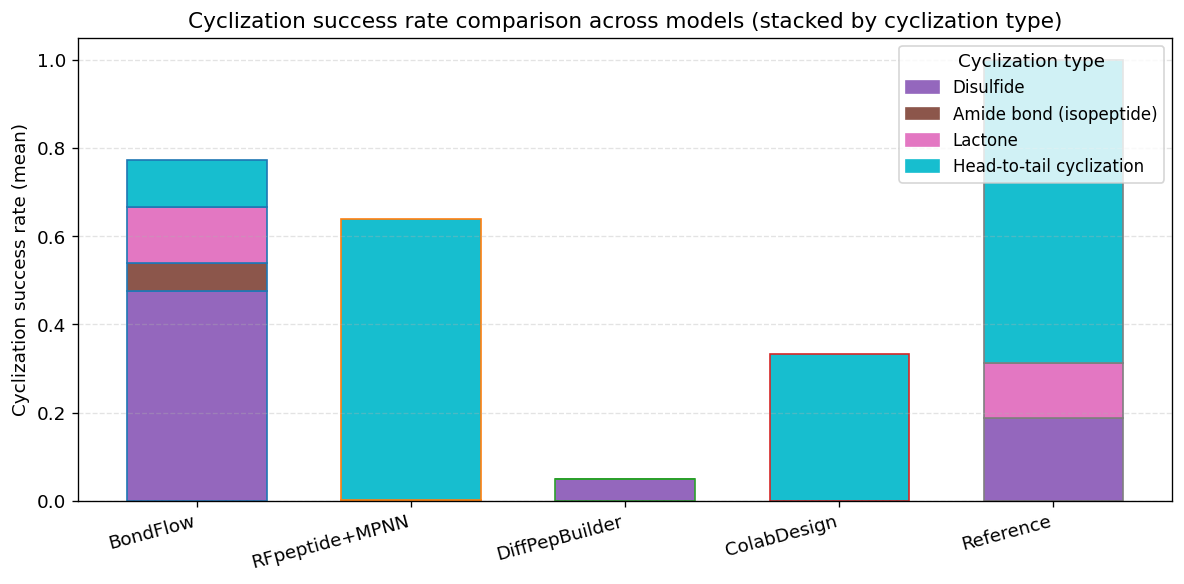

In [ ]:
# 2. Cyclization success rate (stacked by cyclization type; including reference)
fig, ax = plt.subplots(figsize=(10, 5))
plot_cyclization_stacked_success(ax, dfs, ref_type_by_bench)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1640547/1787125736.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


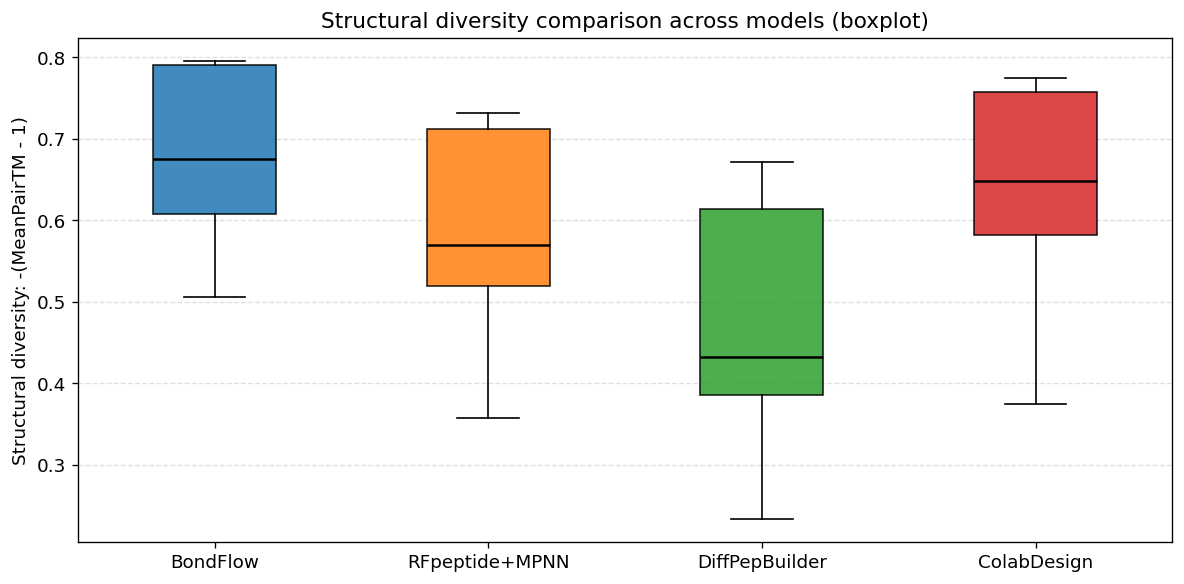

In [ ]:
# 3. Structural diversity (boxplot)
fig, ax = plt.subplots(figsize=(10, 5))
plot_diversity_box(ax, dfs)
plt.tight_layout()
plt.show()


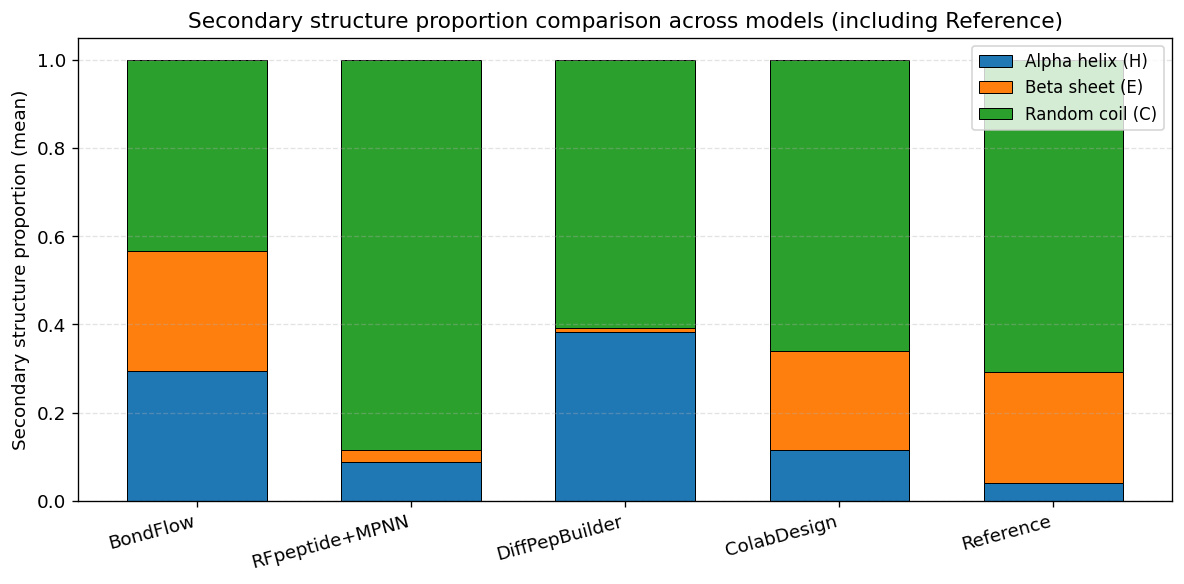

In [ ]:
# 4. Secondary-structure proportion comparison (including reference; stacked bars)
fig, ax = plt.subplots(figsize=(10, 5))
plot_secondary_structure_stacked(ax, dfs)
plt.tight_layout()
plt.show()


## Reference Notes (on Cyclization Type)

The provided CSVs do not include an explicit reference cyclization type field, so this notebook infers the reference part in the stacked cyclization success plot:

- For each benchmark, vote using each model's dominant cyclization type inferred from `Cyclization_Type_Count_*`;
- Use that model's `Cyclization_Success_Rate` as the weight;
- The highest-vote type is used as the reference cyclization type.

If you provide the ground-truth reference cyclization type table (instead of inference), I can update the notebook to use strict labels.